# 실습 4-1 : 결측치 및 이상치 처리

#### **<실습 내용>**

1. 결측치 처리
- 결측치 확인
- 결측치 제거
- 결측치 대치 (값 기반, 통계 기반, 머신러닝 기반 (KNN Imputer), 시계열 보간법)

2. 이상치 탐지
- 이상치 확인
- IQR 기반 이상치 제거

## 분석 준비

### 주요 라이브러리 호출

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split

### 데이터 불러오기

In [2]:
data = pd.read_csv('dataset/day4-1_data.csv')
print("데이터 크기:", data.shape)

data.head()

데이터 크기: (1567, 592)


,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


---

## 1) 결측치 처리

> **결측치 처리** 방법으로는 대표적으로 두 가지 방식이 있음
> 1. **제거**: 결측치가 존재하는 입력변수 또는 행을 제거
> 2. **대치 (보간)**: 결측치를 특정 값으로 대체

### 1-1) 결측치 확인

In [3]:
# 데이터의 각 위치가 결측치인지 확인
data.isnull()

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,True,True,True,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1562,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1563,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
1564,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1565,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [4]:
# 변수별 결측치 개수 확인
data.isnull().sum()

Time          0
0             6
1             7
2            14
3            14
             ..
586           1
587           1
588           1
589           1
Pass/Fail     0
Length: 592, dtype: int64

In [ ]:
# 실무에서 자주 사용하는 결측치 확인 코드

# 1. 데이터 전체 결측치 개수 / 비율 한눈에 보기
print("전체 결측치 개수:", data.isnull().sum().sum())  #변수마다 결측치 갯수를 구한 뒤 모든 열의 갯수들을 더한 것.

전체 결측치 개수: 41951


In [8]:
# 2. 변수별 결측치 비율(%)
print(data.isnull().mean() * 100)

Time         0.000000
0            0.382897
1            0.446713
2            0.893427
3            0.893427
               ...   
586          0.063816
587          0.063816
588          0.063816
589          0.063816
Pass/Fail    0.000000
Length: 592, dtype: float64


In [9]:
# 3. 결측치 비율 높은 순 정렬

# .sort_values() : 값을 기준으로 정렬해주는 함수 
# ascending=False : 내림차순(큰 값 -> 작은 값)으로 정렬 (True면 오름차순)

print(data.isnull().mean().sort_values(ascending=False))

293    0.911934
292    0.911934
157    0.911934
158    0.911934
492    0.855775
         ...   
570    0.000000
571    0.000000
572    0.000000
573    0.000000
574    0.000000
Length: 592, dtype: float64


In [10]:
# 4. 결측치가 존재하는 변수만 보기
print(data.isnull().sum()[data.isnull().sum() > 0])

0       6
1       7
2      14
3      14
4      14
       ..
585     1
586     1
587     1
588     1
589     1
Length: 538, dtype: int64


In [11]:
# 5. 결측치 여부에 따른 변수 개수 확인
print("결측치 있는 변수 수:", (data.isnull().sum() > 0).sum())
print("결측치 없는 변수 수:", (data.isnull().sum() == 0).sum())

결측치 있는 변수 수: 538
결측치 없는 변수 수: 54


In [12]:
# 6. 결측치 요약 표 (DataFrame 형태)

missing_summary = pd.DataFrame({
    "결측개수": data.isnull().sum(),               # 컬럼별 결측치 개수
    "결측비율(%)": data.isnull().mean() * 100,     # 컬럼별 결측치 비율(%)
    "dtype": data.dtypes                          # 컬럼별 데이터 타입 (대치 방법 선택에 참고)
}).query("결측개수 > 0").sort_values("결측비율(%)", ascending=False)                            
   # 결측치가 1개 이상인 컬럼만 남기고 결측 비율이 높은 컬럼부터 정렬

missing_summary

,결측개수,결측비율(%),dtype
292,1429,91.193363,float64
157,1429,91.193363,float64
158,1429,91.193363,float64
293,1429,91.193363,float64
492,1341,85.577537,float64
...,...,...,...
585,1,0.063816,float64
586,1,0.063816,float64
587,1,0.063816,float64
588,1,0.063816,float64


### 1-2) 결측치 제거

> **결측치 제거** 방법을 선택하기 전, 행을 제거할지 변수를 제거할지 먼저 판단해야 함
>
> **판단 기준**
> - 결측 있는 행의 비율이 낮고(예: 5% 미만) 데이터가 충분한 경우 → **행 제거**
> - 특정 변수의 결측 비율이 매우 높은 경우(예: 50% 이상) → 해당 **변수(열) 제거**

In [13]:
# 행을 제거할지 변수를 제거할지 판단하기

# 변수 기준 결측 비율 확인 → 비율이 매우 높은 변수가 있으면 "열 제거" 고려
col_missing_ratio = data.isnull().mean().sort_values(ascending=False)

# 결측 비율이 50%를 넘는 변수 개수 확인
n_high_missing = (col_missing_ratio >= 0.5).sum()
print(f"결측 비율 50% 이상인 변수 개수: {n_high_missing}개")

결측 비율 50% 이상인 변수 개수: 28개


In [14]:
# 행 기준 결측 비율 확인 → 결측 있는 행의 비율이 작으면 "행 제거"로도 데이터 손실이 적음
row_missing_ratio = data.isnull().any(axis=1).mean()
print(f"결측치가 하나라도 있는 행의 비율: {row_missing_ratio * 100:.2f}%")

결측치가 하나라도 있는 행의 비율: 100.00%


In [15]:
# 결측 비율 50% 이상인 변수 이름 뽑기
cols_to_drop = col_missing_ratio[col_missing_ratio >= 0.5].index

# 해당 변수들을 제거
data2 = data.drop(columns=cols_to_drop)

print("변수 제거 전:", data.shape[1], "-> 변수 제거 후:", data2.shape[1])

변수 제거 전: 592 -> 변수 제거 후: 564


### 1-3) 결측치 대치

> **결측치 대치(Single Imputation)** 는 결측치를 하나의 값으로 보완하는 방법임

| 대치 방법 | 사용 시점 |
|---|---|
| 0 | 결측이 "없음"을 의미하는 경우 |
| 매우 큰 값 (99999 등) | 결측 자체를 하나의 신호로 활용하고자 하는 경우 |
| 평균(Mean) | 연속형 변수의 대표적인 대치 방법 |
| 중앙값(Median) | 이상치가 많은 연속형 변수 |
| 최빈값(Mode) | 범주형 변수의 대표적인 대치 방법 |
| Unknown | 결측 자체를 하나의 범주로 취급하고자 하는 경우 |

In [16]:
# 0으로 보간
data_zero = data2.fillna(0)
print("[0으로 보간] 결측치 수:", data_zero.isna().sum().sum())

[0으로 보간] 결측치 수: 0


In [17]:
# 매우 큰 값으로 보간
data_large = data2.fillna(99999)
print("[99999로 보간] 결측치 수:", data_large.isna().sum().sum())

[99999로 보간] 결측치 수: 0


In [18]:
# 변수별 평균으로 보간
data_mean = data2.fillna(data2.mean(numeric_only=True))
print("[평균 보간] 결측치 수:", data_mean.isna().sum().sum())

[평균 보간] 결측치 수: 0


In [19]:
# 변수별 중앙값으로 보간
data_median = data2.fillna(data2.median(numeric_only=True))
print("[중앙값 보간] 결측치 수:", data_median.isna().sum().sum())

[중앙값 보간] 결측치 수: 0


In [20]:
# 특정 변수 1개를 골라, 대치 방법별 값 비교
row_idx = data2.isna().any(axis=1).idxmax()

nan_cols_all = data2.columns[data2.loc[row_idx].isna()]
target_col = nan_cols_all[0]  # 비교할 변수

compare = pd.DataFrame({
    "원본 (NaN)": [data2.loc[row_idx, target_col]],
    "0 대치": [data_zero.loc[row_idx, target_col]],
    "99999 대치": [data_large.loc[row_idx, target_col]],
    "평균 대치": [data_mean.loc[row_idx, target_col]],
    "중앙값 대치": [data_median.loc[row_idx, target_col]]
}, index=[target_col])

print(f"행 {row_idx}, 변수 '{target_col}' 대치 비교:")
compare

행 0, 변수 '112' 대치 비교:


,원본 (NaN),0 대치,99999 대치,평균 대치,중앙값 대치
112,NaN,0.0,99999.0,0.457538,0.46285


### 1-4) KNN Imputer

> **KNN Imputer**는 결측치가 있는 데이터의 최근접 이웃 k개를 찾아, 해당 이웃들의 값의 평균으로 결측치를 보완함
> - NaN이 포함된 변수를 제외한 나머지 변수로 NaN Euclidean Distance를 계산함
> - 거리를 기반으로 유사한 데이터의 값을 가져오는 합리적인 방법임

In [ ]:
data2_sorted = data2.sort_values('Time')  # 시간순 정렬
X = data2_sorted.drop(columns=['Time', 'Pass/Fail'])  # 센서값만 대치 대상
y = data2_sorted['Pass/Fail']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  # 시간 순서 유지
)
# KNN Imputer 시행 전에 train/test set을 먼저 분리해야함.

In [ ]:
cols, idx_train, idx_test = X_train.columns, X_train.index, X_test.index  # 덮어쓰기 전에 저장

imputer = KNNImputer(n_neighbors=5)

X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=cols, index=idx_train)
X_test = pd.DataFrame(imputer.transform(X_test), columns=cols, index=idx_test)

print("[Train] 결측치 수:", X_train.isnull().sum().sum())
print("[Test] 결측치 수:", X_test.isnull().sum().sum())
#이건 시간순을 고려하지 않은 것임

[Train] 결측치 수: 0
[Test] 결측치 수: 0


### 1-5) 시계열 보간법

> 시계열 데이터의 경우 시간 순서를 고려한 보간법이 효과적임
> - **ffill (forward fill)**: 이전 시점의 값으로 채우기
> - **bfill (backward fill)**: 다음 시점의 값으로 채우기
> - **linear**: 위치 기반 선형 보간
> - **time**: 시간 간격에 비례한 선형 보간 (불균등 시간 간격에 적합)

In [23]:
# [예제 1] 소규모 시계열 데이터로 각 보간법 결과 비교

dates = pd.date_range("2026-07-01", "2026-07-08", freq="D")
values = [10, np.nan, np.nan, 40, 50, np.nan, 60, 70]
ts = pd.Series(values, index=dates, name="값")

demo = pd.DataFrame({
    "원본": ts,
    "ffill": ts.ffill(),
    "bfill": ts.bfill(),
    "linear": ts.interpolate(method="linear"),
    "time": ts.interpolate(method="time")
})
print(demo)
print()
print("잔여 NaN 개수:",
      f"ffill: {ts.ffill().isnull().sum()},",
      f"bfill: {ts.bfill().isnull().sum()},",
      f"linear: {ts.interpolate(method='linear').isnull().sum()},",
      f"time: {ts.interpolate(method='time').isnull().sum()}")

              원본  ffill  bfill  linear  time
2026-07-01  10.0   10.0   10.0    10.0  10.0
2026-07-02   NaN   10.0   40.0    20.0  20.0
2026-07-03   NaN   10.0   40.0    30.0  30.0
2026-07-04  40.0   40.0   40.0    40.0  40.0
2026-07-05  50.0   50.0   50.0    50.0  50.0
2026-07-06   NaN   50.0   60.0    55.0  55.0
2026-07-07  60.0   60.0   60.0    60.0  60.0
2026-07-08  70.0   70.0   70.0    70.0  70.0

잔여 NaN 개수: ffill: 0, bfill: 0, linear: 0, time: 0


> **ffill+bfill**: 맨 앞 행이 결측치라 ffill만으로는 채워지지 않는 경우에 사용
> - 먼저 ffill로 채울 수 있는 결측치를 채우고
> - ffill로도 채워지지 않는 맨 앞 결측치는 bfill로 보간

In [ ]:
# [예시 2] 소규모 시계열 데이터로 보간 방법별 동작 확인

dates = pd.date_range("2026-07-01", "2026-07-08", freq="D")
values = [np.nan, 10, np.nan, np.nan, 40, 50, np.nan, np.nan]
ts = pd.Series(values, index=dates, name="값")

ts 

2026-07-01     NaN
2026-07-02    10.0
2026-07-03     NaN
2026-07-04     NaN
2026-07-05    40.0
2026-07-06    50.0
2026-07-07     NaN
2026-07-08     NaN
Freq: D, Name: 값, dtype: float64

In [ ]:
#처음부터 또는 맨 뒤가 NaN일 경우 forward+backward fill을 둘다 해야 결측치가 없게된다.

demo = pd.DataFrame({
    "원본": ts,
    "ffill": ts.ffill(),
    "bfill": ts.bfill(),
    "linear": ts.interpolate(method="linear"),
    "time": ts.interpolate(method="time"),
    "ffill+bfill": ts.ffill().bfill(),
})
print(demo)
print()
print("잔여 NaN 개수:",
      f"ffill: {ts.ffill().isna().sum()},",
      f"bfill: {ts.bfill().isna().sum()},",
      f"linear: {ts.interpolate(method='linear').isna().sum()},",
      f"time: {ts.interpolate(method='time').isna().sum()},",
      f"ffill+bfill: {ts.ffill().bfill().isna().sum()}")

              원본  ffill  bfill  linear  time  ffill+bfill
2026-07-01   NaN    NaN   10.0     NaN   NaN         10.0
2026-07-02  10.0   10.0   10.0    10.0  10.0         10.0
2026-07-03   NaN   10.0   40.0    20.0  20.0         10.0
2026-07-04   NaN   10.0   40.0    30.0  30.0         10.0
2026-07-05  40.0   40.0   40.0    40.0  40.0         40.0
2026-07-06  50.0   50.0   50.0    50.0  50.0         50.0
2026-07-07   NaN   50.0    NaN    50.0  50.0         50.0
2026-07-08   NaN   50.0    NaN    50.0  50.0         50.0

잔여 NaN 개수: ffill: 1, bfill: 2, linear: 1, time: 1, ffill+bfill: 0


---

## 2) 이상치 처리

> **이상치(Outlier)** 는 데이터의 일반적인 패턴에서 크게 벗어난 값을 의미함

In [27]:
# 변수별 평균으로 보간한 데이터 생성
data_imputed = data2.fillna(data2.median(numeric_only=True))  # 숫자형 컬럼만 중앙값으로 결측치 대체
print(data_imputed.isna().sum().sum())  # 남은 결측치 수 확인 (0이면 결측치 없음)

0


### 2-1) Box Plot

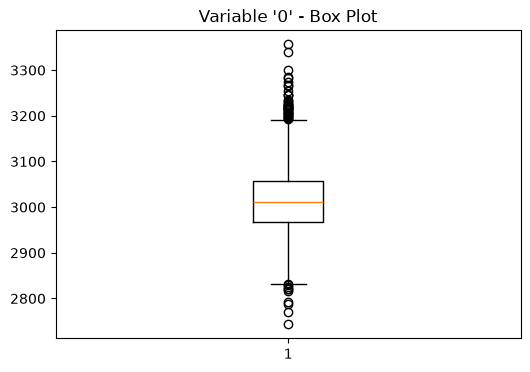

In [28]:
plt.figure(figsize=(6, 4))
plt.boxplot(data_imputed['0'])
plt.title("Variable '0' - Box Plot")
plt.show()

### 2-2) IQR 기반 이상치 제거

In [29]:
q1 = data_imputed['0'].quantile(0.25)  # 1사분위수 (하위 25%)
q3 = data_imputed['0'].quantile(0.75)  # 3사분위수 (상위 25%)
iqr = q3 - q1  # 사분위 범위 (IQR)

lower_bound = q1 - 1.5 * iqr  # 이상치 판단 하한선
upper_bound = q3 + 1.5 * iqr  # 이상치 판단 상한선

# 하한선~상한선 범위 안에 있는 데이터만 남김 (이상치 제거)
data_cleaned = data_imputed[(data_imputed['1'] >= lower_bound) & (data_imputed['1'] <= upper_bound)]

print("이상치 제거 전:", len(data_imputed))
print("이상치 제거 후:", len(data_cleaned))

이상치 제거 전: 1567
이상치 제거 후: 2


In [30]:
data_cleaned = data_imputed.copy()  # 원본 유지하고 복사본으로 작업

numeric_cols = data_cleaned.select_dtypes(include='number').columns  # 숫자형 컬럼만 선택

for column in numeric_cols:  # 숫자형 컬럼에 대해서만 반복
    q1 = data_cleaned[column].quantile(0.25)  # 1사분위수
    q3 = data_cleaned[column].quantile(0.75)  # 3사분위수
    iqr = q3 - q1  # 사분위 범위 (IQR)

    lower_bound = q1 - 1.5 * iqr  # 이상치 판단 하한선
    upper_bound = q3 + 1.5 * iqr  # 이상치 판단 상한선

    data_cleaned = data_cleaned[(data_cleaned[column] >= lower_bound) & (data_cleaned[column] <= upper_bound)]

print("이상치 제거 전:", len(data_imputed))
print("이상치 제거 후:", len(data_cleaned))

이상치 제거 전: 1567
이상치 제거 후: 3


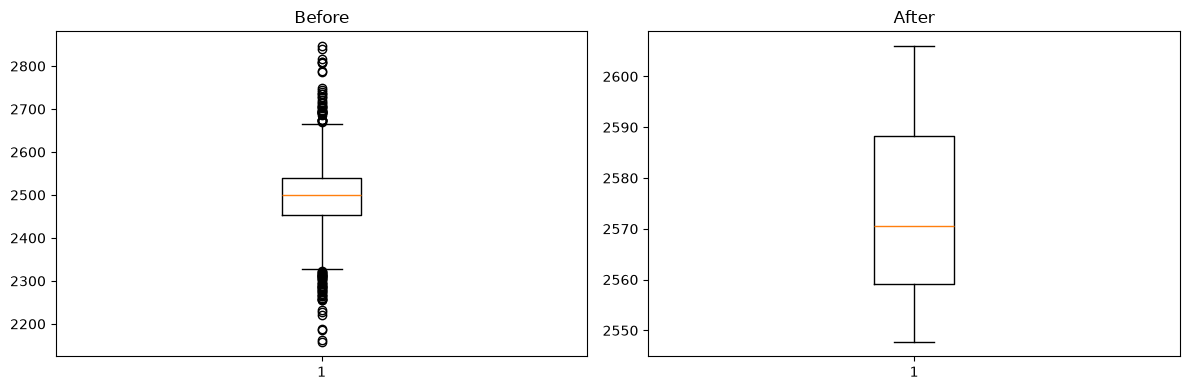

In [31]:
# 이상치 제거 전후 Box Plot 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(data_imputed['1']); axes[0].set_title("Before")
axes[1].boxplot(data_cleaned['1']); axes[1].set_title("After")
plt.tight_layout()
plt.show()

---

## 3) Vibe Coding 실습

**[과제 1]**

지수는 IQR 기반 이상치 제거 코드를 적용했더니 데이터가 3개만 남는 현상을 발견했습니다.

이 상태로는 실제 분석에 데이터를 전혀 쓸 수 없다고 판단하여 AI와 상의하여 왜 이런 현상이 발생하는지 원인을 파악하고 데이터를 과도하게 잃지 않으면서 이상치를 처리할 수 있는 방법을 찾아보려 합니다. 

AI와의 대화를 통해 원인과 대안을 정리하고 그중 하나를 실제로 적용하여 이상치 제거 전후 데이터 크기를 비교해 보세요.

[프롬프트]
data2 데이터에서 결측치를 중앙값으로 채운 data_imputed를 만들고 IQR 기반 이상치 제거를 했더니 데이터가 3개밖에 남지 않았어.

1. 왜 이런 현상이 발생했을까?
2. 데이터를 과도하게 잃지 않으면서도 이상치를 처리할 수 있는 방법은 무엇이 있을까?


[AI의 대답]

## 1. 왜 3개만 남았을까?

**중앙값 대치 자체가 주원인은 아닙니다.** 핵심은 노트북의 **IQR 제거 방식**입니다.

```python
for column in numeric_cols:  # 숫자형 563개 컬럼
    ...
    data_cleaned = data_cleaned[(... 범위 안 ...)]  # 매 컬럼마다 행 삭제
```

### 원인 ① **563개 변수에 연속으로 IQR 적용 (교집합 필터)**

- `data2`는 센서 변수가 **약 563개**입니다.
- 컬럼마다 IQR 밖 행을 **삭제**하므로, 행은 **모든 변수에서 동시에 "정상"**이어야 남습니다.
- 컬럼당 3~5%만 제거해도 누적되면 급격히 줄어듭니다.

실제로 같은 방식으로 돌리면:

| 단계 | 행 수 |
|------|------|
| 시작 | 1,567 |
| 컬럼 0~4 적용 후 | 1,323 |
| 컬럼 ~100 | 98 |
| 컬럼 ~207 | **3** |

→ **고차원 데이터 + 컬럼별 순차 제거** 조합이 데이터를 거의 없앱니다.

### 원인 ② **변수마다 스케일·분포가 다름**

- 센서마다 값 범위가 크게 다릅니다 (수천 vs 0.00x).
- IQR은 **변수별로 따로** 계산하므로, 한 행이 A 변수에서는 정상이어도 B 변수에서 이상치로 잘리기 쉽습니다.

### 원인 ③ **`Pass/Fail`(타겟)도 숫자형 루프에 포함**

- `numeric_cols`에 `Pass/Fail`이 들어가 타겟까지 IQR 필터에 걸립니다.
- 타겟은 이상치 제거 대상이 아닙니다.

### (부차) 중앙값 대치의 영향

- 결측을 중앙값으로 채우면 분포가 **중앙으로 몰리는** 컬럼이 생길 수 있습니다.
- 하지만 **3개만 남는 현상의 주원인은 아닙니다.**

---

## 2. 데이터를 덜 잃으면서 이상치를 다루는 방법

| 방법 | 설명 | 장점 |
|------|------|------|
| **① Winsorization (캡핑)** | IQR 밖 값을 경계값으로 **대체**, 행은 유지 | 행 수 유지 |
| **② 핵심 변수만 IQR** | 563개 전부가 아니라 **일부 센서만** 적용 | 과도한 삭제 방지 |
| **③ 행 기준 규칙** | "563개 중 **k개 이상** 이상치일 때만" 행 제거 | 교집합보다 합리적 |
| **④ Z-score 클리핑** | \|z\| > 3 값을 경계로 자름 | 구현 단순 |
| **⑤ 삭제 대신 모델링 단계 처리** | `RobustScaler`, 트리 모델 등 | 분석용 데이터 보존 |

실무에서는 **행 삭제보다 캡핑(①) 또는 행 기준 규칙(③)** 을 더 자주 씁니다.

---

## 정리

1. **왜 3개?** → 563개 숫자형 변수에 IQR 제거를 **순차 적용**해, 모든 변수에서 동시에 정상인 행만 남기는 **교집합 필터**가 되었기 때문입니다.
2. **대안?** → 전 컬럼 삭제 대신 **Winsorization**, **핵심 변수만 IQR**, **행 단위 이상치 개수 기준 제거** 등이 적절합니다. 타겟 `Pass/Fail`은 이상치 처리에서 **제외**해야 합니다.

아래 코드 셀에서 **Winsorization**과 **행 기준 규칙(k=20)** 을 적용해 전후를 비교합니다.


[대안1] Winsorization: 1567행 (100% 유지, 극단값만 대체)

[대안2] 행 기준 (IQR 이탈 변수 < 20개인 행만 유지)
  제거된 행: 485 / 1567
  남은 행  : 1082 (69.0%)


,rows,retention(%)
원본(data_imputed),1567,100.00
기존(컬럼별 순차 IQR),3,0.19
대안1(Winsorization),1567,100.00
대안2(행 기준 k=20),1082,69.05


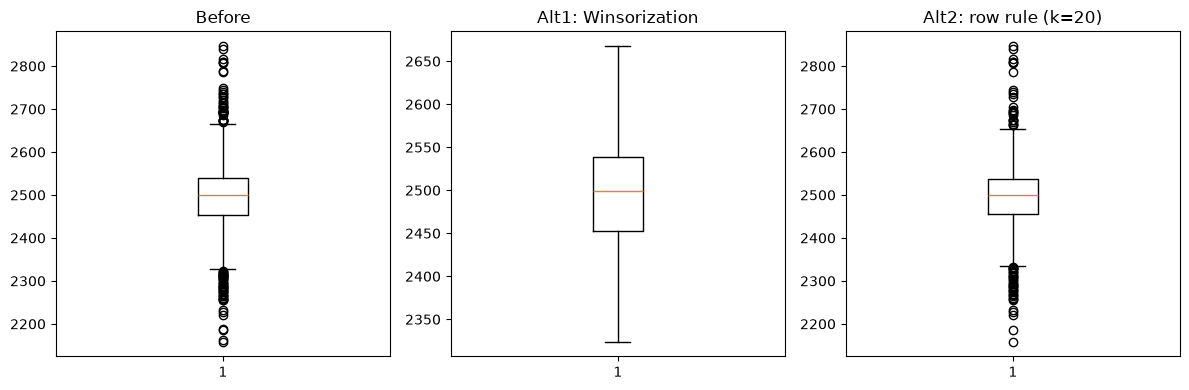

In [33]:
# [과제 1] 이상치 처리 대안 비교 — Winsorization & 행 기준 규칙

# ── 공통 준비 ──
data_imputed = data2.fillna(data2.median(numeric_only=True))
feature_cols = data_imputed.select_dtypes(include="number").columns.drop("Pass/Fail")


def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr


def iqr_mask(series, k=1.5):
    low, high = iqr_bounds(series, k)
    return series.between(low, high)


# [기존] 모든 컬럼 순차 IQR 제거 (교집합) → 데이터 거의 소멸
old_way = data_imputed.copy()
for col in feature_cols:
    old_way = old_way[iqr_mask(old_way[col])]


# ── 대안 1) Winsorization — 행 유지, IQR 밖 값만 경계로 캡핑 ──
data_winsor = data_imputed.copy()
for col in feature_cols:
    low, high = iqr_bounds(data_winsor[col])
    data_winsor[col] = data_winsor[col].clip(lower=low, upper=high)

print(f"[대안1] Winsorization: {len(data_winsor)}행 (100% 유지, 극단값만 대체)")


# ── 대안 2) 행 기준 규칙 — k개 이상 IQR 이탈 시에만 행 제거 ──
# k=20 선택 이유:
# - 센서 변수 약 562개 중, 행마다 IQR 이탈 변수 수의 중앙값 ≈ 16, 75% 분위 ≈ 21
# - k=20이면 "소수 센서만 튀는 행"은 유지, 여러 센서에서 동시에 튀는 행만 제거
# - k=10(약 14% 유지)은 너무 공격적, k=20(약 69% 유지)은 데이터 보존·이상치 제거 균형
K_ROW = 20

outlier_count = (~data_imputed[feature_cols].apply(iqr_mask)).sum(axis=1)
data_row_rule = data_imputed[outlier_count < K_ROW].copy()

print(f"\n[대안2] 행 기준 (IQR 이탈 변수 < {K_ROW}개인 행만 유지)")
print(f"  제거된 행: {(outlier_count >= K_ROW).sum()} / {len(data_imputed)}")
print(f"  남은 행  : {len(data_row_rule)} ({len(data_row_rule)/len(data_imputed)*100:.1f}%)")


# ── 전후 비교 ───────────────────────────────────────────────
compare_df = pd.DataFrame(
    {
        "rows": {
            "원본(data_imputed)": len(data_imputed),
            "기존(컬럼별 순차 IQR)": len(old_way),
            "대안1(Winsorization)": len(data_winsor),
            f"대안2(행 기준 k={K_ROW})": len(data_row_rule),
        },
        "retention(%)": {
            "원본(data_imputed)": 100.0,
            "기존(컬럼별 순차 IQR)": round(len(old_way) / len(data_imputed) * 100, 2),
            "대안1(Winsorization)": 100.0,
            f"대안2(행 기준 k={K_ROW})": round(len(data_row_rule) / len(data_imputed) * 100, 2),
        },
    }
)
display(compare_df)

# Box Plot 비교 (컬럼 '1' 예시)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].boxplot(data_imputed["1"]); axes[0].set_title("Before")
axes[1].boxplot(data_winsor["1"]); axes[1].set_title("Alt1: Winsorization")
axes[2].boxplot(data_row_rule["1"]); axes[2].set_title(f"Alt2: row rule (k={K_ROW})")
plt.tight_layout()
plt.show()